In [ ]:
# Prepare for NLP Training

import pandas as pd

# Load the jobs with VSRS for fdf
df = pd.read_csv("fdf_all_vsrs_filtered.csv")

# Randomly shuffle the rows, but always in the same way
shuffled = df.sample(frac=1, random_state=42)

# Split into 400 (manual) and 1240 (automated) rows
df_400 = shuffled.iloc[:400].copy()
df_1240 = shuffled.iloc[400:].copy()

# Save them
df_400.to_csv("vsrs_400.csv", index=False)
df_1240.to_csv("vsrs_1240.csv", index=False)

In [ ]:
# Manual Classification

import pandas as pd

# Load the VSRS dataset for manual classification
df = pd.read_csv("vsrs_400.csv")

# Manually classified row indices by category
amber  =  [5,15,16,17,25,27,33,39,40,42,46,53,54,56,57,61,62,65,66,67,70,73,89,91,92,95,96,99,102,103,107,112,113,118,120,121,122,129,130,131,132,135,137,140,141,142,144,146,147,149,155,159,160,163,167,174,178,179,182,183,184,195,198,206,208,209,210,212,213,224,226,227,229,233,238,241,243,246,252,255,257,259,264,265,267,269,271,272,282,284,286,289,291,292,295,300,305,306,309,310,317,321,322,324,326,328,336,337,346,348,353,363,369,372,375,376,380,382,388,390,394,397,398]
green  =  [0,1,2,4,6,7,8,11,12,13,14,18,19,20,23,24,26,28,29,30,31,32,34,35,36,37,38,41,43,44,47,48,49,50,51,52,55,58,59,60,63,64,68,69,71,72,74,76,77,78,80,81,83,84,85,93,94,97,98,101,104,105,106,108,110,114,115,116,117,119,123,126,127,128,133,134,136,138,139,145,148,150,151,152,153,156,157,158,162,164,165,166,170,171,173,175,176,177,180,185,186,187,188,190,191,192,193,200,202,203,204,205,211,215,216,218,219,221,222,228,230,231,232,234,235,236,237,242,244,245,247,248,249,251,254,256,258,260,261,262,263,270,273,275,276,277,278,280,281,285,287,290,293,294,297,299,302,303,304,308,312,313,314,315,316,318,319,325,327,329,330,331,332,334,335,338,339,340,341,343,344,349,350,351,352,354,355,356,357,358,360,361,364,365,366,370,371,373,374,377,379,381,383,384,385,386,387,389,391,395,399]
blue   =  [3,9,10,21,22,45,75,79,82,86,87,88,90,100,109,111,124,125,143,154,161,168,169,172,181,189,194,196,197,199,201,207,214,217,220,223,225,239,240,250,253,266,268,274,279,283,288,296,298,301,307,311,320,323,333,342,345,347,359,362,367,368,378,392,393,396]

# Count the number of jobs in each classification
print('Amber:', len(amber)) # VSRS potentially illegal
print('Green:', len(green)) # VSRS likelu legal
print('Blue:', len(blue))   # Irrelevant to VSRS for the UK

# Create separate copies for classification, relevance and legality
df1=df.copy()
df2=df.copy()

# Assign the classification to each job
df.loc[amber, "classification"] = "amber"
df.loc[green, "classification"] = "green"
df.loc[blue, "classification"] = "blue"

# Assign the relevance to each job
df1.loc[amber, "relevance"] = "yes"
df1.loc[green, "relevance"] = "yes"
df1.loc[blue, "relevance"] = "no"

# Assign the legality to each job
df2.loc[amber, "legality"] = "no"
df2.loc[green, "legality"] = "yes"
df2.loc[blue, "legality"] = "ignore"
# Remove jobs classified as irrelevant to the legality analysis
df2=df2[df2["legality"] != "ignore"].copy()

# Save the classified, relevance, and legality datasets
df.to_csv("vsrs_400_classified.csv", index=False)
df1.to_csv("vsrs_400_relevance.csv", index=False)
df2.to_csv("vsrs_400_legality.csv", index=False)

Amber: 123
Green: 211
Blue: 66


In [2]:
# Extraction Exploration Tool (optional)

import pandas as pd

# Load desired CSV file
csv_file = "vsrs_400_classified.csv"

# Keyword to search for
keyword = "restrict"

# Read CSV
df = pd.read_csv(csv_file)
df = df.reset_index(drop=True)

# Filter rows where the keyword appears in the "description" column
filtered = df[
    df["description"]
    .fillna("")
    .astype(str)
    .str.contains(keyword, regex=False)
]

# Show matching VSRS and row/index
print(f"Found {len(filtered)} matching rows.")
print("-+" * 40)
print("\nMatching VSRS:\n")

for index, row in filtered.iterrows():
    print(f"Index : {index}")
    print(f"Title : {row['title']}")
    print(f"VSRS  : {row['vsrs']}")
    print("-" * 80)

Found 82 matching rows.
-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+

Matching VSRS:

Index : 2
Title : Guidance, Control and Navigation Engineer - Undergraduate Placement
VSRS  : Applicants must have the right to work in the UK. Due to the nature of our work, we are unable to sponsor or take over sponsorship of an employment visa.
--------------------------------------------------------------------------------
Index : 7
Title : Sumer Intern Electrical Engineer
VSRS  : Retention and Career Development: Recognising the importance of retaining talented individuals, we offer sponsorship, career development support, and high
--------------------------------------------------------------------------------
Index : 10
Title : Industrial Placement - Electronic Engineering
VSRS  : This could be you, and if so you may have the option of sponsorship and paid engineering work throughout your degree studies.
-------------------------------------------------------

----------------------------------------
Logistic Regression (1)

Top features for Amber:
permanent: 1.358
the permanent: 1.245
permanent right: 1.104
must have: 0.820
you must: 0.725
uk: 0.642
or: 0.602
visa: 0.531
right to: 0.494
the uk: 0.493

Top features for Blue:
of sponsorship: 0.570
career development: 0.564
development: 0.564
career: 0.494
this could: 0.417
the option: 0.417
if so: 0.417
throughout your: 0.417
work throughout: 0.417
so you: 0.417

Top features for Green:
eligible: 0.549
of: 0.533
eligible to: 0.510
to: 0.485
for: 0.485
be eligible: 0.456
uk for: 0.452
must be: 0.436
duration of: 0.418
duration: 0.418
              precision    recall  f1-score   support

       amber       0.96      0.96      0.96        25
        blue       1.00      0.54      0.70        13
       green       0.85      0.98      0.91        42

    accuracy                           0.90        80
   macro avg       0.94      0.82      0.86        80
weighted avg       0.91      0.90      0

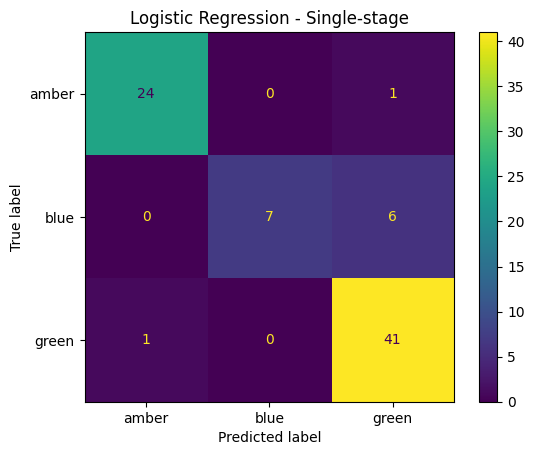

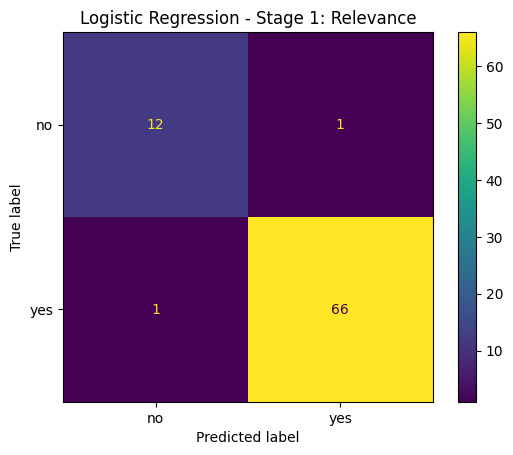

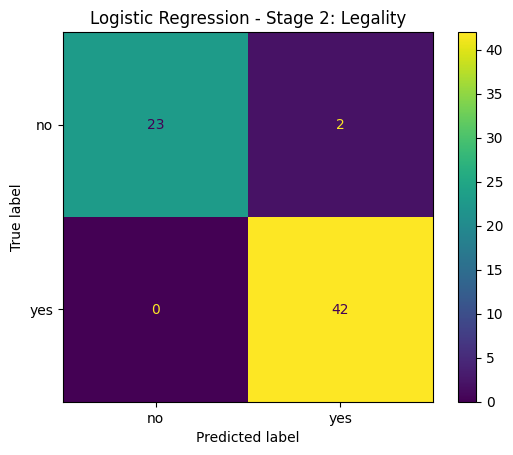

In [21]:
# Classifier: Logistic Regression (LR): Single & Dual Stages

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer #Text -> Numbers

from sklearn.linear_model import LogisticRegression

from sklearn.pipeline import Pipeline

from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

def LR1(test):

    print("-" * 40)
    print("Logistic Regression (1)")

    df = pd.read_csv("vsrs_400_classified.csv")

    vsrs = df["vsrs"]
    classification = df["classification"]

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        vsrs,
        classification,
        test_size=0.2, #20% for testing
        random_state=42, #same order
        stratify=classification #ensure balanced representation of classes in train and test sets
    )

    # Create model
    model = Pipeline([
        ("text_to_numbers", TfidfVectorizer(
            ngram_range=(1,2)) #learn phrases of 1 or 2 words
        ),
        ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
    ])

    # Train
    model.fit(X_train, y_train)

    # Features
    vectorizer = model.named_steps["text_to_numbers"]
    classifier = model.named_steps["classifier"]
    vocab = vectorizer.get_feature_names_out()
    coefficients = classifier.coef_

    for i, class_name in enumerate(model.classes_):
        print(f"\nTop features for {class_name.title()}:")
        top = coefficients[i].argsort()[-10:][::-1]
        for index in top:
            print(f"{vocab[index]}: {coefficients[i][index]:.3f}")
    
    # Test
    predictions = model.predict(X_test)

	# Report & Matrix
    print(classification_report(y_test, predictions))
    matrix=ConfusionMatrixDisplay.from_predictions(y_test, predictions)
    matrix.ax_.set_title("Logistic Regression - Single-stage")
    plt.savefig("Matrix_LR1.svg", format="svg", bbox_inches="tight")

    # Predict classification for new test text
    print("Predicted classification of test:", model.predict(test))

    # Summary
    print("\nSummary Results:")
    correct = (y_test == predictions).sum()
    incorrect = (y_test != predictions).sum()
    print("Correct:", correct)
    print("Incorrect:", incorrect)
    print("Total:", len(y_test))

def LR2_1(test):

    print("-" * 40)
    print("Logistic Regression (2.1 - Relevance)")

    df = pd.read_csv("vsrs_400_relevance.csv")

    vsrs = df["vsrs"]
    relevance = df["relevance"]

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        vsrs,
        relevance,
        test_size=0.2, #20% for testing
        random_state=42, #same order
        stratify=relevance #ensure balanced representation of classes in train and test sets
    )

    # Create model
    model = Pipeline([
        ("text_to_numbers", TfidfVectorizer(
            ngram_range=(1,2)) #learn phrases of 1 or 2 words
        ),
        ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
    ])

    # Train
    model.fit(X_train, y_train)

    # Features
    vectorizer = model.named_steps["text_to_numbers"]
    classifier = model.named_steps["classifier"]
    vocab = vectorizer.get_feature_names_out()
    coefficients = classifier.coef_[0]
    
    print("\nClasses:", model.classes_)
    print(f"\nTop features for {model.classes_[1].title()}:")
    top = coefficients.argsort()[-10:][::-1]
    for index in top:
        print(f"{vocab[index]}: {coefficients[index]:.3f}")
    print(f"\nTop features for {model.classes_[0].title()}:")
    top = coefficients.argsort()[:10]
    for index in top:
        print(f"{vocab[index]}: {coefficients[index]:.3f}")
    
    # Test
    predictions = model.predict(X_test)

	# Report & Matrix
    print(classification_report(y_test, predictions))
    matrix=ConfusionMatrixDisplay.from_predictions(y_test, predictions)
    matrix.ax_.set_title("Logistic Regression - Stage 1: Relevance")
    plt.savefig("Matrix_LR2_1.svg", format="svg", bbox_inches="tight")

    # Predict relevance for new test text
    print("Predicted relevance of test:", model.predict(test))

    # Summary
    print("\nSummary Results:")
    correct = (y_test == predictions).sum()
    incorrect = (y_test != predictions).sum()
    print("Correct:", correct)
    print("Incorrect:", incorrect)
    print("Total:", len(y_test))

    return model

def LR2_2(test):

    print("-" * 40)
    print("Logistic Regression (2.2 - Legality)")

    df = pd.read_csv("vsrs_400_legality.csv")

    vsrs = df["vsrs"]
    legality = df["legality"]

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        vsrs,
        legality,
        test_size=0.2, #20% for testing
        random_state=42, #same order
        stratify=legality #ensure balanced representation of classes in train and test sets
    )

    # Create model
    model = Pipeline([
        ("text_to_numbers", TfidfVectorizer(
            ngram_range=(1,2)) #learn phrases of 1 or 2 words
        ),
        ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
    ])

    # Train
    model.fit(X_train, y_train)

    # Features
    vectorizer = model.named_steps["text_to_numbers"]
    classifier = model.named_steps["classifier"]
    vocab = vectorizer.get_feature_names_out()
    coefficients = classifier.coef_[0]

    print("\nClasses:", model.classes_)
    print(f"\nTop features for {model.classes_[1].title()}:")
    top = coefficients.argsort()[-10:][::-1]
    for index in top:
        print(f"{vocab[index]}: {coefficients[index]:.3f}")
    print(f"\nTop features for {model.classes_[0].title()}:")
    top = coefficients.argsort()[:10]
    for index in top:
        print(f"{vocab[index]}: {coefficients[index]:.3f}")

    # Test
    predictions = model.predict(X_test)

	# Report & Matrix
    print(classification_report(y_test, predictions))
    matrix=ConfusionMatrixDisplay.from_predictions(y_test, predictions)
    matrix.ax_.set_title("Logistic Regression - Stage 2: Legality")
    plt.savefig("Matrix_LR2_2.svg", format="svg", bbox_inches="tight")

    # Predict legality for new test text
    print("Predicted legality of test:", model.predict(test))

    # Summary
    print("\nSummary Results:")
    correct = (y_test == predictions).sum()
    incorrect = (y_test != predictions).sum()
    print("Correct:", correct)
    print("Incorrect:", incorrect)
    print("Total:", len(y_test))

    return model

def LR2(test):
    print("-" * 40)
    print("Logistic Regression (2 - Combined)")

    # Stage 1: Relevance
    relevance = lr2_1.predict(test)[0] #[0] obtain one and only item in array

    print("Stage 1 - Relevance:", relevance)

    # If not relevant → blue
    if relevance == "no":
        prediction = "blue"
        print("Stage 2 - Legality: unknown")

    # Stage 2: Legality (if relevant)
    else:
        legality = lr2_2.predict(test)[0] #[0] obtain one and only item in array
        print("Stage 2 - Legality:", legality)

        if legality == "yes":
            prediction = "green"
        else:
            prediction = "amber"
            
    print("Prediction of test:", prediction)

test_LR1 = ["Insert testing statement here."]
LR1(test_LR1)

test_LR2_1 = ["Insert testing statement here."]
lr2_1 = LR2_1(test_LR2_1)

test_LR2_2 = ["Insert testing statement here."]
lr2_2 = LR2_2(test_LR2_2)

test_LR2 = ["Insert testing statement here."]
LR2(test_LR2)

----------------------------------------
LinearSVC (1)

Top features for Amber:
permanent: 1.408
the permanent: 1.154
permanent right: 0.964
eu: 0.644
or: 0.595
citizen: 0.546
visa: 0.540
must have: 0.530
time: 0.529
you must: 0.502

Top features for Blue:
for more: 0.577
more information: 0.577
states: 0.563
united states: 0.563
states at: 0.507
see the: 0.490
please see: 0.490
sponsored: 0.478
students: 0.449
23: 0.442

Top features for Green:
of: 0.586
for: 0.563
eligible: 0.515
legal right: 0.510
to: 0.488
required: 0.474
you have: 0.453
in: 0.445
legal: 0.443
experience: 0.435
              precision    recall  f1-score   support

       amber       1.00      0.96      0.98        25
        blue       1.00      0.62      0.76        13
       green       0.88      1.00      0.93        42

    accuracy                           0.93        80
   macro avg       0.96      0.86      0.89        80
weighted avg       0.93      0.93      0.92        80

Predicted classification of te

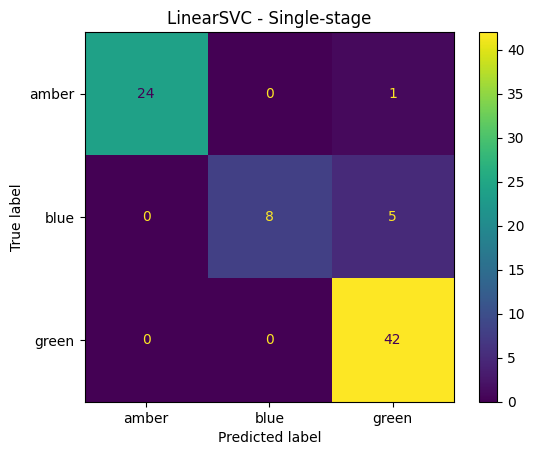

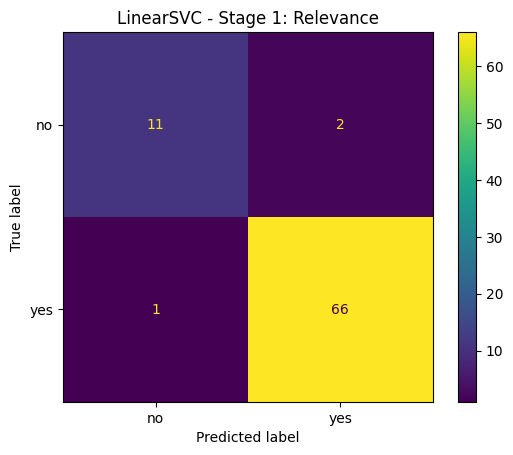

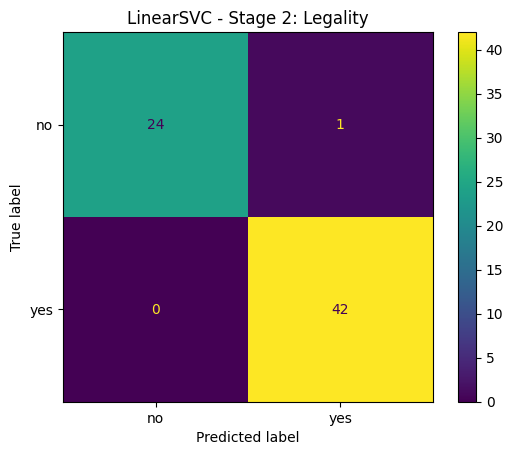

In [22]:
# Classifier: LinearSVC: Single & Dual Stages

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer #Text -> Numbers

from sklearn.svm import LinearSVC

from sklearn.pipeline import Pipeline

from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

def LS1(test):

    print("-" * 40)
    print("LinearSVC (1)")

    df = pd.read_csv("vsrs_400_classified.csv")

    vsrs = df["vsrs"]
    classification = df["classification"]

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        vsrs,
        classification,
        test_size=0.2, #20% for testing
        random_state=42, #same order
        stratify=classification #ensure balanced representation of classes in train and test sets
    )

    # Create model
    model = Pipeline([
        ("text_to_numbers", TfidfVectorizer(
            ngram_range=(1,2)) #learn phrases of 1 or 2 words
        ),
        ("classifier", LinearSVC(class_weight="balanced"))
    ])

    # Train
    model.fit(X_train, y_train)

    # Features
    vectorizer = model.named_steps["text_to_numbers"]
    classifier = model.named_steps["classifier"]
    vocab = vectorizer.get_feature_names_out()
    coefficients = classifier.coef_

    for i, class_name in enumerate(model.classes_):
        print(f"\nTop features for {class_name.title()}:")
        top = coefficients[i].argsort()[-10:][::-1]
        for index in top:
            print(f"{vocab[index]}: {coefficients[i][index]:.3f}")
    
    # Test
    predictions = model.predict(X_test)

	# Report & Matrix
    print(classification_report(y_test, predictions))
    matrix=ConfusionMatrixDisplay.from_predictions(y_test, predictions)
    matrix.ax_.set_title("LinearSVC - Single-stage")
    plt.savefig("Matrix_LS1.svg", format="svg", bbox_inches="tight")

    # Predict classification for new test text
    print("Predicted classification of test:", model.predict(test))

    # Summary
    print("\nSummary Results:")
    correct = (y_test == predictions).sum()
    incorrect = (y_test != predictions).sum()
    print("Correct:", correct)
    print("Incorrect:", incorrect)
    print("Total:", len(y_test))

def LS2_1(test):

    print("-" * 40)
    print("LinearSVC (2.1 - Relevance)")

    df = pd.read_csv("vsrs_400_relevance.csv")

    vsrs = df["vsrs"]
    relevance = df["relevance"]

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        vsrs,
        relevance,
        test_size=0.2, #20% for testing
        random_state=42, #same order
        stratify=relevance #ensure balanced representation of classes in train and test sets
    )

    # Create model
    model = Pipeline([
        ("text_to_numbers", TfidfVectorizer(
            ngram_range=(1,2)) #learn phrases of 1 or 2 words
        ),
        ("classifier", LinearSVC(class_weight="balanced"))
    ])

    # Train
    model.fit(X_train, y_train)

    # Features
    vectorizer = model.named_steps["text_to_numbers"]
    classifier = model.named_steps["classifier"]
    vocab = vectorizer.get_feature_names_out()
    coefficients = classifier.coef_[0]
    
    print("\nClasses:", model.classes_)
    print(f"\nTop features for {model.classes_[1].title()}:")
    top = coefficients.argsort()[-10:][::-1]
    for index in top:
        print(f"{vocab[index]}: {coefficients[index]:.3f}")
    print(f"\nTop features for {model.classes_[0].title()}:")
    top = coefficients.argsort()[:10]
    for index in top:
        print(f"{vocab[index]}: {coefficients[index]:.3f}")
    
    # Test
    predictions = model.predict(X_test)

	# Report & Matrix
    print(classification_report(y_test, predictions))
    matrix=ConfusionMatrixDisplay.from_predictions(y_test, predictions)
    matrix.ax_.set_title("LinearSVC - Stage 1: Relevance")
    plt.savefig("Matrix_LS2_1.svg", format="svg", bbox_inches="tight")

    # Predict relevance for new test text
    print("Predicted relevance of test:", model.predict(test))

    # Summary
    print("\nSummary Results:")
    correct = (y_test == predictions).sum()
    incorrect = (y_test != predictions).sum()
    print("Correct:", correct)
    print("Incorrect:", incorrect)
    print("Total:", len(y_test))

    return model

def LS2_2(test):

    print("-" * 40)
    print("LinearSVC (2.2 - Legality)")

    df = pd.read_csv("vsrs_400_legality.csv")

    vsrs = df["vsrs"]
    legality = df["legality"]

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        vsrs,
        legality,
        test_size=0.2, #20% for testing
        random_state=42, #same order
        stratify=legality #ensure balanced representation of classes in train and test sets
    )

    # Create model
    model = Pipeline([
        ("text_to_numbers", TfidfVectorizer(
            ngram_range=(1,2)) #learn phrases of 1 or 2 words
        ),
        ("classifier", LinearSVC(class_weight="balanced"))
    ])

    # Train
    model.fit(X_train, y_train)

    # Features
    vectorizer = model.named_steps["text_to_numbers"]
    classifier = model.named_steps["classifier"]
    vocab = vectorizer.get_feature_names_out()
    coefficients = classifier.coef_[0]

    print("\nClasses:", model.classes_)
    print(f"\nTop features for {model.classes_[1].title()}:")
    top = coefficients.argsort()[-10:][::-1]
    for index in top:
        print(f"{vocab[index]}: {coefficients[index]:.3f}")
    print(f"\nTop features for {model.classes_[0].title()}:")
    top = coefficients.argsort()[:10]
    for index in top:
        print(f"{vocab[index]}: {coefficients[index]:.3f}")

    # Test
    predictions = model.predict(X_test)

	# Report & Matrix
    print(classification_report(y_test, predictions))
    matrix=ConfusionMatrixDisplay.from_predictions(y_test, predictions)
    matrix.ax_.set_title("LinearSVC - Stage 2: Legality")
    plt.savefig("Matrix_LS2_2.svg", format="svg", bbox_inches="tight")

    # Predict legality for new test text
    print("Predicted legality of test:", model.predict(test))

    # Summary
    print("\nSummary Results:")
    correct = (y_test == predictions).sum()
    incorrect = (y_test != predictions).sum()
    print("Correct:", correct)
    print("Incorrect:", incorrect)
    print("Total:", len(y_test))

    return model

def LS2(test):
    print("-" * 40)
    print("LinearSVC (2 - Combined)")

    # Stage 1: Relevance
    relevance = ls2_1.predict(test)[0] #[0] obtain one and only item in array

    print("Stage 1 - Relevance:", relevance)

    # If not relevant → blue
    if relevance == "no":
        prediction = "blue"
        print("Stage 2 - Legality: unknown")

    # Stage 2: Legality (if relevant)
    else:
        legality = ls2_2.predict(test)[0] #[0] obtain one and only item in array
        print("Stage 2 - Legality:", legality)

        if legality == "yes":
            prediction = "green"
        else:
            prediction = "amber"

    print("Prediction of test:", prediction)

test_LS1 = ["Insert testing statement here."]
LS1(test_LS1)

test_LS2_1 = ["Insert testing statement here."]
ls2_1 = LS2_1(test_LS2_1)

test_LS2_2 = ["Insert testing statement here."]
ls2_2 = LS2_2(test_LS2_2)

test_LS2 = ["Insert testing statement here."]
LS2(test_LS2)

In [3]:
# 5-fold Cross-Validation Classifier: Logistical Regression (LR): Single & Dual Stages

import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer #Text -> Numbers

from sklearn.linear_model import LogisticRegression

from sklearn.pipeline import Pipeline

from sklearn.model_selection import StratifiedKFold, cross_val_score

def LR1():

    print("-" * 40)
    print("Logistic Regression (1)")

    df = pd.read_csv("vsrs_400_classified.csv")

    vsrs = df["vsrs"]
    classification = df["classification"]

    # Create model
    model = Pipeline([
        ("text_to_numbers", TfidfVectorizer(
            ngram_range=(1,2)) #learn phrases of 1 or 2 words
        ),
        ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
    ])

    # 5-fold cross-validation
    cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
    )

    # Macro-F1
    f1_scores = cross_val_score(
    model,
    vsrs,
    classification,
    cv=cv,
    scoring="f1_macro"
    )

    # Accuracy
    accuracy_scores = cross_val_score(
    model,
    vsrs,
    classification,
    cv=cv,
    scoring="accuracy"
)
    print("\n5-Fold Cross-Validation:")
    print("\nMacro-F1 scores:", [f"{x:.3f}" for x in f1_scores])
    print(f"Mean ± SD: {f1_scores.mean():.3f} ± {f1_scores.std():.3f}")
    print("\nAccuracy scores:", [f"{x:.3f}" for x in accuracy_scores])
    print(f"Mean ± SD: {accuracy_scores.mean():.3f} ± {accuracy_scores.std():.3f}")

def LR2_1():

    print("-" * 40)
    print("Logistic Regression (2.1 - Relevance)")

    df = pd.read_csv("vsrs_400_relevance.csv")

    vsrs = df["vsrs"]
    relevance = df["relevance"]

    # Create model
    model = Pipeline([
        ("text_to_numbers", TfidfVectorizer(
            ngram_range=(1,2)) #learn phrases of 1 or 2 words
        ),
        ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
    ])

    # 5-fold cross-validation
    cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
    )

    # Macro-F1
    f1_scores = cross_val_score(
    model,
    vsrs,
    relevance,
    cv=cv,
    scoring="f1_macro"
    )

    # Accuracy
    accuracy_scores = cross_val_score(
    model,
    vsrs,
    relevance,
    cv=cv,
    scoring="accuracy"
)
    print("\n5-Fold Cross-Validation:")
    print("\nMacro-F1 scores:", [f"{x:.3f}" for x in f1_scores])
    print(f"Mean ± SD: {f1_scores.mean():.3f} ± {f1_scores.std():.3f}")
    print("\nAccuracy scores:", [f"{x:.3f}" for x in accuracy_scores])
    print(f"Mean ± SD: {accuracy_scores.mean():.3f} ± {accuracy_scores.std():.3f}")

def LR2_2():

    print("-" * 40)
    print("Logistic Regression (2.2 - Legality)")

    df = pd.read_csv("vsrs_400_legality.csv")

    vsrs = df["vsrs"]
    legality = df["legality"]

    # Create model
    model = Pipeline([
        ("text_to_numbers", TfidfVectorizer(
            ngram_range=(1,2)) #learn phrases of 1 or 2 words
        ),
        ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
    ])

    # 5-fold cross-validation
    cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
    )

    # Macro-F1
    f1_scores = cross_val_score(
    model,
    vsrs,
    legality,
    cv=cv,
    scoring="f1_macro"
    )

    # Accuracy
    accuracy_scores = cross_val_score(
    model,
    vsrs,
    legality,
    cv=cv,
    scoring="accuracy"
)
    print("\n5-Fold Cross-Validation:")
    print("\nMacro-F1 scores:", [f"{x:.3f}" for x in f1_scores])
    print(f"Mean ± SD: {f1_scores.mean():.3f} ± {f1_scores.std():.3f}")
    print("\nAccuracy scores:", [f"{x:.3f}" for x in accuracy_scores])
    print(f"Mean ± SD: {accuracy_scores.mean():.3f} ± {accuracy_scores.std():.3f}")

LR1()

LR2_1()

LR2_2()

----------------------------------------
Logistic Regression (1)

5-Fold Cross-Validation:

Macro-F1 scores: ['0.867', '0.926', '0.951', '0.912', '0.792']
Mean ± SD: 0.890 ± 0.056

Accuracy scores: ['0.887', '0.938', '0.950', '0.925', '0.850']
Mean ± SD: 0.910 ± 0.037
----------------------------------------
Logistic Regression (2.1 - Relevance)

5-Fold Cross-Validation:

Macro-F1 scores: ['0.951', '0.881', '0.933', '0.908', '0.881']
Mean ± SD: 0.911 ± 0.028

Accuracy scores: ['0.975', '0.938', '0.963', '0.950', '0.938']
Mean ± SD: 0.953 ± 0.015
----------------------------------------
Logistic Regression (2.2 - Legality)

5-Fold Cross-Validation:

Macro-F1 scores: ['0.934', '0.934', '0.901', '0.984', '0.967']
Mean ± SD: 0.944 ± 0.029

Accuracy scores: ['0.940', '0.940', '0.910', '0.985', '0.970']
Mean ± SD: 0.949 ± 0.026


In [ ]:
# 5-fold Cross-Validation Classifier: LinearSVC: Single & Dual Stages

import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer #Text -> Numbers

from sklearn.svm import LinearSVC

from sklearn.pipeline import Pipeline

from sklearn.model_selection import StratifiedKFold, cross_val_score

def LS1():

    print("-" * 40)
    print("LinearSVC (1)")

    df = pd.read_csv("vsrs_400_classified.csv")

    vsrs = df["vsrs"]
    classification = df["classification"]

    # Create model
    model = Pipeline([
        ("text_to_numbers", TfidfVectorizer(
            ngram_range=(1,2)) #learn phrases of 1 or 2 words
        ),
        ("classifier", LinearSVC(class_weight="balanced"))
    ])

    # 5-fold cross-validation
    cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
    )

    # Macro-F1
    f1_scores = cross_val_score(
    model,
    vsrs,
    classification,
    cv=cv,
    scoring="f1_macro"
    )

    # Accuracy
    accuracy_scores = cross_val_score(
    model,
    vsrs,
    classification,
    cv=cv,
    scoring="accuracy"
)
    print("\n5-Fold Cross-Validation:")
    print("\nMacro-F1 scores:", [f"{x:.3f}" for x in f1_scores])
    print(f"Mean ± SD: {f1_scores.mean():.3f} ± {f1_scores.std():.3f}")
    print("\nAccuracy scores:", [f"{x:.3f}" for x in accuracy_scores])
    print(f"Mean ± SD: {accuracy_scores.mean():.3f} ± {accuracy_scores.std():.3f}")

def LS2_1():

    print("-" * 40)
    print("LinearSVC (2.2 - Relevance)")

    df = pd.read_csv("vsrs_400_relevance.csv")

    vsrs = df["vsrs"]
    relevance = df["relevance"]

    # Create model
    model = Pipeline([
        ("text_to_numbers", TfidfVectorizer(
            ngram_range=(1,2)) #learn phrases of 1 or 2 words
        ),
        ("classifier", LinearSVC(class_weight="balanced"))
    ])

    # 5-fold cross-validation
    cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
    )

    # Macro-F1
    f1_scores = cross_val_score(
    model,
    vsrs,
    relevance,
    cv=cv,
    scoring="f1_macro"
    )

    # Accuracy
    accuracy_scores = cross_val_score(
    model,
    vsrs,
    relevance,
    cv=cv,
    scoring="accuracy"
)
    print("\n5-Fold Cross-Validation:")
    print("\nMacro-F1 scores:", [f"{x:.3f}" for x in f1_scores])
    print(f"Mean ± SD: {f1_scores.mean():.3f} ± {f1_scores.std():.3f}")
    print("\nAccuracy scores:", [f"{x:.3f}" for x in accuracy_scores])
    print(f"Mean ± SD: {accuracy_scores.mean():.3f} ± {accuracy_scores.std():.3f}")

def LS2_2():

    print("-" * 40)
    print("LinearSVC (2.2 - Legality)")

    df = pd.read_csv("vsrs_400_legality.csv")

    vsrs = df["vsrs"]
    legality = df["legality"]

    # Create model
    model = Pipeline([
        ("text_to_numbers", TfidfVectorizer(
            ngram_range=(1,2)) #learn phrases of 1 or 2 words
        ),
        ("classifier", LinearSVC(class_weight="balanced"))
    ])

    # 5-fold cross-validation
    cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
    )

    # Macro-F1
    f1_scores = cross_val_score(
    model,
    vsrs,
    legality,
    cv=cv,
    scoring="f1_macro"
    )

    # Accuracy
    accuracy_scores = cross_val_score(
    model,
    vsrs,
    legality,
    cv=cv,
    scoring="accuracy"
)
    print("\n5-Fold Cross-Validation:")
    print("\nMacro-F1 scores:", [f"{x:.3f}" for x in f1_scores])
    print(f"Mean ± SD: {f1_scores.mean():.3f} ± {f1_scores.std():.3f}")
    print("\nAccuracy scores:", [f"{x:.3f}" for x in accuracy_scores])
    print(f"Mean ± SD: {accuracy_scores.mean():.3f} ± {accuracy_scores.std():.3f}")

LS1()

LS2_1()

LS2_2()

----------------------------------------
LinearSVC (1)

5-Fold Cross-Validation:

Macro-F1 scores: ['0.878', '0.926', '0.962', '0.912', '0.883']
Mean ± SD: 0.912 ± 0.030

Accuracy scores: ['0.900', '0.938', '0.963', '0.925', '0.912']
Mean ± SD: 0.927 ± 0.022
----------------------------------------
LinearSVC (2.2 - Relevance)

5-Fold Cross-Validation:

Macro-F1 scores: ['0.951', '0.862', '0.954', '0.902', '0.908']
Mean ± SD: 0.915 ± 0.034

Accuracy scores: ['0.975', '0.925', '0.975', '0.950', '0.950']
Mean ± SD: 0.955 ± 0.019
----------------------------------------
LinearSVC (2.2 - Legality)

5-Fold Cross-Validation:

Macro-F1 scores: ['0.950', '0.984', '0.935', '0.984', '0.983']
Mean ± SD: 0.967 ± 0.021

Accuracy scores: ['0.955', '0.985', '0.940', '0.985', '0.985']
Mean ± SD: 0.970 ± 0.019


In [8]:
# 5-fold Cross-Validation: By 'sample_sizes'

import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer #Text -> Numbers

from sklearn.svm import LinearSVC

from sklearn.pipeline import Pipeline

from sklearn.model_selection import StratifiedKFold, cross_val_score

# Define desired sample sizes (up to 400)
sample_sizes = [50, 100, 150, 200, 250, 300, 350, 400]

def LS1():

    print("-" * 40)
    print("LinearSVC (1)")
    results = []

    df = pd.read_csv("vsrs_400_classified.csv")

    # Create model
    model = Pipeline([
        ("text_to_numbers", TfidfVectorizer(
            ngram_range=(1,2)) #learn phrases of 1 or 2 words
        ),
        ("classifier", LinearSVC(class_weight="balanced"))
    ])

    # 5-fold cross-validation
    cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
    )

    # Loop through sample sizes
    for size in sample_sizes:

        df_sample = df.iloc[:size]

        vsrs = df_sample["vsrs"]
        classification = df_sample["classification"]

        # Macro-F1
        f1_scores = cross_val_score(
        model,
        vsrs,
        classification,
        cv=cv,
        scoring="f1_macro"
        )

        # Accuracy
        accuracy_scores = cross_val_score(
        model,
        vsrs,
        classification,
        cv=cv,
        scoring="accuracy"
        )

        results.append({
        "sample_size": size,
        "f1_mean": f1_scores.mean(),
        "f1_sd": f1_scores.std(),
        "accuracy_mean": accuracy_scores.mean(),
        "accuracy_sd": accuracy_scores.std()
        })

    return pd.DataFrame(results)

def LS2_1():

    print("-" * 40)
    print("LinearSVC (2.2 - Relevance)")
    results = []

    df = pd.read_csv("vsrs_400_relevance.csv")

    # Create model
    model = Pipeline([
        ("text_to_numbers", TfidfVectorizer(
            ngram_range=(1,2)) #learn phrases of 1 or 2 words
        ),
        ("classifier", LinearSVC(class_weight="balanced"))
    ])

    # 5-fold cross-validation
    cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
    )

    # Loop through sample sizes
    for size in sample_sizes:

        df_sample = df.iloc[:size]

        vsrs = df_sample["vsrs"]
        relevance = df_sample["relevance"]

        # Macro-F1
        f1_scores = cross_val_score(
        model,
        vsrs,
        relevance,
        cv=cv,
        scoring="f1_macro"
        )

        # Accuracy
        accuracy_scores = cross_val_score(
        model,
        vsrs,
        relevance,
        cv=cv,
        scoring="accuracy"
        )

        results.append({
        "sample_size": size,
        "f1_mean": f1_scores.mean(),
        "f1_sd": f1_scores.std(),
        "accuracy_mean": accuracy_scores.mean(),
        "accuracy_sd": accuracy_scores.std()
        })

    return pd.DataFrame(results)

def LS2_2():

    print("-" * 40)
    print("LinearSVC (2.2 - Legality)")
    results = []

    df = pd.read_csv("vsrs_400_legality.csv")

    # Create model
    model = Pipeline([
        ("text_to_numbers", TfidfVectorizer(
            ngram_range=(1,2)) #learn phrases of 1 or 2 words
        ),
        ("classifier", LinearSVC(class_weight="balanced"))
    ])

    # 5-fold cross-validation
    cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
    )

    for size in sample_sizes:

        df_sample = df.iloc[:size]

        vsrs = df_sample["vsrs"]
        legality = df_sample["legality"]

        # Macro-F1
        f1_scores = cross_val_score(
        model,
        vsrs,
        legality,
        cv=cv,
        scoring="f1_macro"
        )

        # Accuracy
        accuracy_scores = cross_val_score(
        model,
        vsrs,
        legality,
        cv=cv,
        scoring="accuracy"
        )

        results.append({
        "sample_size": size,
        "f1_mean": f1_scores.mean(),
        "f1_sd": f1_scores.std(),
        "accuracy_mean": accuracy_scores.mean(),
        "accuracy_sd": accuracy_scores.std()
        })

    return pd.DataFrame(results)

ls1=LS1()
ls2_1=LS2_1()
ls2_2=LS2_2()

----------------------------------------
LinearSVC (1)
----------------------------------------
LinearSVC (2.2 - Relevance)
----------------------------------------
LinearSVC (2.2 - Legality)


In [ ]:
# Metrics by sample size across models
print(ls1)
print("-"*80)
print(ls2_1)
print("-"*80)
print(ls2_2)
print("-"*80)

   sample_size   f1_mean     f1_sd  accuracy_mean  accuracy_sd
0           50  0.478126  0.132195       0.760000     0.101980
1          100  0.541488  0.063934       0.760000     0.058310
2          150  0.806131  0.068953       0.873333     0.032660
3          200  0.809182  0.095465       0.850000     0.059161
4          250  0.820724  0.034530       0.864000     0.014967
5          300  0.889869  0.035223       0.910000     0.022608
6          350  0.877213  0.019641       0.894286     0.029416
7          400  0.912030  0.030397       0.927500     0.021506
--------------------------------------------------------------------------------
   sample_size   f1_mean     f1_sd  accuracy_mean  accuracy_sd
0           50  0.467836  0.011696       0.880000     0.040000
1          100  0.531373  0.144519       0.870000     0.050990
2          150  0.768119  0.154555       0.926667     0.032660
3          200  0.784486  0.108843       0.915000     0.030000
4          250  0.860169  0.073412   

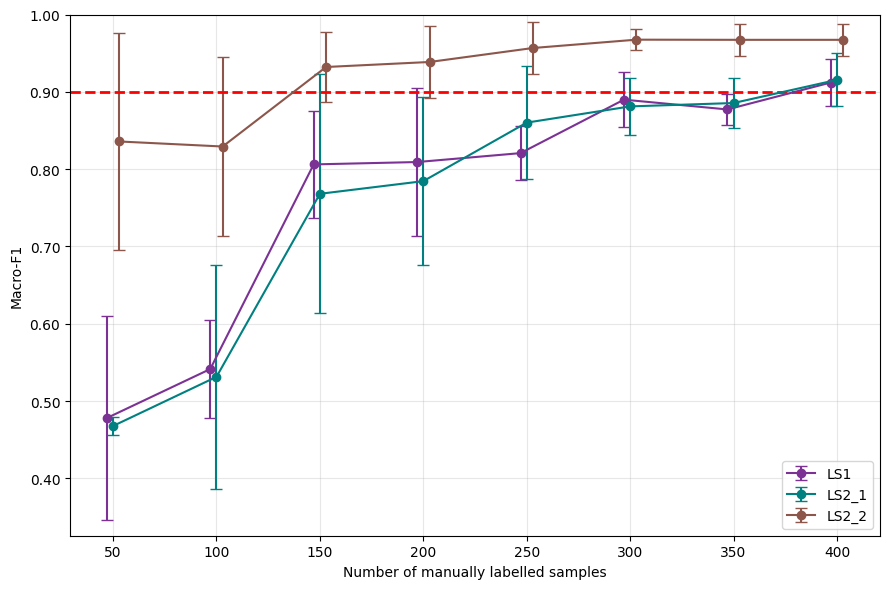

In [33]:
# Plot the 5-Fold Cross-Validation macro-F1 by sample size across models

import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

plt.figure(figsize=(9, 6))

offset=3

plt.errorbar(
    ls1["sample_size"]-offset,
    ls1["f1_mean"],
    yerr=ls1["f1_sd"],
    color="#7B3294",
    marker="o",
    capsize=4,
    label="LS1"
)

plt.errorbar(
    ls2_1["sample_size"],
    ls2_1["f1_mean"],
    yerr=ls2_1["f1_sd"],
    color="#008080",
    marker="o",
    capsize=4,
    label="LS2_1"
)

plt.errorbar(
    ls2_2["sample_size"]+offset,
    ls2_2["f1_mean"],
    yerr=ls2_2["f1_sd"],
    color="#8C564B",
    marker="o",
    capsize=4,
    label="LS2_2"
)

plt.grid(alpha=0.3)

plt.xlabel("Number of manually labelled samples")
plt.ylabel("Macro-F1")

plt.xticks(sample_sizes)
y_min = min(
    (ls1["f1_mean"] - ls1["f1_sd"]).min(),
    (ls2_1["f1_mean"] - ls2_1["f1_sd"]).min(),
    (ls2_2["f1_mean"] - ls2_2["f1_sd"]).min()
)
plt.ylim(y_min - 0.02, 1)
plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

plt.legend()
plt.axhline(y=0.9, linestyle="--", linewidth=2, color="red")
plt.tight_layout()
plt.savefig("macro-f1_by_size.svg", format="svg")

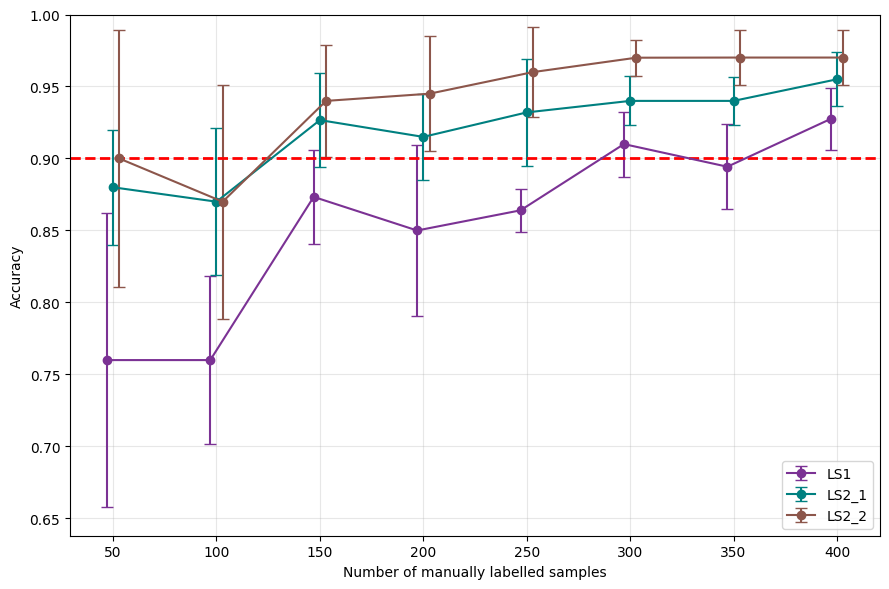

In [34]:
# Plot the 5-Fold Cross-Validation Accuracy by sample size across models

import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

plt.figure(figsize=(9, 6))

offset = 3

plt.errorbar(
    ls1["sample_size"]-offset,
    ls1["accuracy_mean"],
    yerr=ls1["accuracy_sd"],
    color="#7B3294",
    marker="o",
    capsize=4,
    label="LS1"
)

plt.errorbar(
    ls2_1["sample_size"],
    ls2_1["accuracy_mean"],
    yerr=ls2_1["accuracy_sd"],
    color="#008080",
    marker="o",
    capsize=4,
    label="LS2_1"
)

plt.errorbar(
    ls2_2["sample_size"]+offset,
    ls2_2["accuracy_mean"],
    yerr=ls2_2["accuracy_sd"],
    color="#8C564B",
    marker="o",
    capsize=4,
    label="LS2_2"
)

plt.xlabel("Number of manually labelled samples")
plt.ylabel("Accuracy")

plt.xticks(sample_sizes)
y_min = min(
    (ls1["accuracy_mean"] - ls1["accuracy_sd"]).min(),
    (ls2_1["accuracy_mean"] - ls2_1["accuracy_sd"]).min(),
    (ls2_2["accuracy_mean"] - ls2_2["accuracy_sd"]).min()
)
plt.ylim(y_min - 0.02, 1)
plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

plt.legend()
plt.axhline(y=0.9, linestyle="--", linewidth=2, color="red")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("accuracy_by_size.svg", format="svg")